<center>
<b><font size="10">Telecom X - Parte 2</font></b>
</center>

<br/>
<center>
<b><font color="blue" size="6">Prevenção Cancelamento</font></b>
</center>


 <b><font color="blue">MISSÃO:</font></b>

 - Desenvolvendo modelos preditivos capazes de prever quais clientes têm maior chance de cancelar seus serviços. Assim a empresa pode antecipar qualquer problema de evasão, para isso será construído um pipeline para etapa de modelagem inicial



 <b><font color="blue">OBJETIVO DO DESAFIO:</font></b>

 - Preparar os dados para a modelagem

 - Realizar análise de correlação e seleção de variáveis.

 - Treinar modelos de classificação.

 - Avaliar o desempenho dos modelos com métricas.

 - Interpretação dos resultados, incluindo a importância das variáveis.

 - Conclusão estratégica apontando os principais fatores que influenciam a evasão.

<b><font color="blue">SERÁ TRABALHADO NESTE DESAFIO:</font></b>

 - Pré-processamento de dados para Machine Learning

 - Construção e avaliação de modelos preditivos

 - Interpretação dos resultados e entrega de insights

 - Comunicação técnica com foco estratégico

# <b><font color="blue" size="4">EXTRAÇÃO</font></b>


---



Para iniciar análise, importado os [dados da API da Telecom X](https://drive.google.com/file/d/1Dul9YDaHCzXo8jFJKceEhzarRkjwLYnK/view?usp=drive_link). Esses dados estão disponíveis no formato `CSV` e contêm as informações já tratadas.

In [ ]:
import pandas as pd
import requests
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import gdown
from IPython.display import display, HTML


In [ ]:
# ID do arquivo no Google Drive
file_id = '1Dul9YDaHCzXo8jFJKceEhzarRkjwLYnK'
url = f'https://drive.google.com/uc?id={file_id}'

# Baixar o arquivo
gdown.download(url, 'dados_tratados.csv', quiet=False)

# Ler os dados
dados = pd.read_csv('dados_tratados.csv')
dados.head()


# <b><font color="blue" size="4">PREPARAÇÃO DOS DADOS</font></b>


---



## <b><font color="blue">Remoção de Colunas Irrelevantes</font></b>

Removemos colunas que continham IDs, estimativas ou valores já representados em outras variáveis. Essas informações não agregam valor à previsão da evasão e poderiam comprometer o desempenho dos modelos.

In [7]:
import pandas as pd
import gdown

# ID do arquivo no Google Drive
file_id = '1Dul9YDaHCzXo8jFJKceEhzarRkjwLYnK'
url = f'https://drive.google.com/uc?id={file_id}'

# Baixar o arquivo
gdown.download(url, 'dados_tratados.csv', quiet=True)

# Ler os dados
dados = pd.read_csv('dados_tratados.csv')

# Calcular correlação apenas entre colunas numéricas
dados_numericos = dados.select_dtypes(include=['number', 'bool'])
correlacao = dados_numericos.corr().abs()

# Pegar pares com alta correlação
pares_correlacionados = [
    (col1, col2)
    for col1 in correlacao.columns
    for col2 in correlacao.columns
    if col1 != col2 and correlacao.loc[col1, col2] > 0.95
]

print("PARES DE COLUNAS COM ALTA CORRELAÇÃO:")
print('-'*41)
for col1, col2 in pares_correlacionados:
    print(f"{col1}  🔛  {col2}")

PARES DE COLUNAS COM ALTA CORRELAÇÃO:
-----------------------------------------
Meses_de_Contrato  🔛  tempo_estimado_meses
Valor_Mensal  🔛  Conta_Diarias
tempo_estimado_meses  🔛  Meses_de_Contrato
Conta_Diarias  🔛  Valor_Mensal


In [8]:
# Remover as colunas com alta correlação
dados = dados.drop(['ID_Cliente', 'tempo_estimado_meses', 'Conta_Diarias', 'Valor_Total'], axis=1)

# Remover registros onde o valor é 'Não informado'
dados = dados[dados['Cancelamento'] != 'Não informado']


dados.head()

,Cancelamento,Gênero,Idoso,Possui_Companheiro,Possui_Dependentes,Meses_de_Contrato,Telefone_Ativo,Multiplas_Linhas,Tipo_Internet,Seguranca_Online,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Forma_Pagamento,Valor_Mensal
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9


## <b><font color="blue">Encoding</font></b>

O processo iniciou-se com a identificação dos valores únicos de cada coluna. Na sequência, as variáveis categóricas foram convertidas para o formato numérico, etapa necessária para compatibilidade com algoritmos de machine learning. A codificação foi realizada por meio de uma técnica apropriada, o one-hot encoding.

In [11]:
# Para saber os valores únicos por coluna e quantidade.
from IPython.display import display, HTML

for col in dados.select_dtypes(include='object').columns:
    titulo = f"<strong style='font-size: 15px;'>  {col.upper()}</strong>"
    display(HTML(titulo))
    display(dados[col].value_counts(dropna=False).head(3).to_frame(name='Frequência'))
    print("-" * 35)

,Frequência
Cancelamento,
No,5163
Yes,1869


-----------------------------------


,Frequência
Gênero,
Male,3549
Female,3483


-----------------------------------


,Frequência
Possui_Companheiro,
No,3639
Yes,3393


...

-----------------------------------


,Frequência
Fatura_Digital,
Yes,4168
No,2864


-----------------------------------


,Frequência
Forma_Pagamento,
Electronic check,2365
Mailed check,1604
Bank transfer (automatic),1542


-----------------------------------


In [12]:
# Passo 1: Mapear os valores para binário
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)
    dados = dados.replace({'Yes': 1, 'No': 0})
    dados = dados.replace({'Female': 1, 'Male': 0})
    dados = dados.replace({'True': 1, 'False': 0})

dados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7255
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Cancelamento          7032 non-null   int64  
 1   Gênero                7032 non-null   int64  
 2   Idoso                 7032 non-null   int64  
 3   Possui_Companheiro    7032 non-null   int64  
 4   Possui_Dependentes    7032 non-null   int64  
 5   Meses_de_Contrato     7032 non-null   int64  
 6   Telefone_Ativo        7032 non-null   int64  
 7   Multiplas_Linhas      7032 non-null   object 
 8   Tipo_Internet         7032 non-null   object 
 9   Seguranca_Online      7032 non-null   object 
 10  Backup_Online         7032 non-null   object 
 11  Protecao_Dispositivo  7032 non-null   object 
 12  Suporte_Tecnico       7032 non-null   object 
 13  Streaming_TV          7032 non-null   object 
 14  Streaming_Filmes      7032 non-null   object 
 15  Tipo_Contrato         7032

In [13]:
# Passo 2: Identificar colunas que têm só 0 e 1
binarias = [col for col in dados.columns if set(dados[col].dropna().unique()).issubset({0, 1})]

# Passo 3: Converter essas colunas para booleano
dados[binarias] = dados[binarias].astype(bool)

dados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7255
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Cancelamento          7032 non-null   bool   
 1   Gênero                7032 non-null   bool   
 2   Idoso                 7032 non-null   bool   
 3   Possui_Companheiro    7032 non-null   bool   
 4   Possui_Dependentes    7032 non-null   bool   
 5   Meses_de_Contrato     7032 non-null   int64  
 6   Telefone_Ativo        7032 non-null   bool   
 7   Multiplas_Linhas      7032 non-null   object 
 8   Tipo_Internet         7032 non-null   object 
 9   Seguranca_Online      7032 non-null   object 
 10  Backup_Online         7032 non-null   object 
 11  Protecao_Dispositivo  7032 non-null   object 
 12  Suporte_Tecnico       7032 non-null   object 
 13  Streaming_TV          7032 non-null   object 
 14  Streaming_Filmes      7032 non-null   object 
 15  Tipo_Contrato         7032

In [14]:
# Passo 4: One-hot encoding para todas as colunas categóricas multiclasse
dados = pd.get_dummies(dados, drop_first=True)

dados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7255
Data columns (total 30 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Cancelamento                              7032 non-null   bool   
 1   Gênero                                    7032 non-null   bool   
 2   Idoso                                     7032 non-null   bool   
 3   Possui_Companheiro                        7032 non-null   bool   
 4   Possui_Dependentes                        7032 non-null   bool   
 5   Meses_de_Contrato                         7032 non-null   int64  
 6   Telefone_Ativo                            7032 non-null   bool   
 7   Fatura_Digital                            7032 non-null   bool   
 8   Valor_Mensal                              7032 non-null   float64
 9   Multiplas_Linhas_1                        7032 non-null   bool   
 10  Multiplas_Linhas_No phone service        

In [15]:
# Passo 5: Calcular novamente a correlação apenas entre colunas numéricas
dados_numericos = dados.select_dtypes(include=['number', 'bool'])
correlacao = dados_numericos.corr().abs()

# Pegar pares com alta correlação
pares_correlacionados = [
    (col1, col2)
    for col1 in correlacao.columns
    for col2 in correlacao.columns
    if col1 != col2 and correlacao.loc[col1, col2] > 0.95
]

print("🔁 PARES DE COLUNAS COM ALTA CORRELAÇÃO:")
print('-'*40)
for col1, col2 in pares_correlacionados:
    print(f"{col1}  🔛  {col2}")


🔁 PARES DE COLUNAS COM ALTA CORRELAÇÃO:
----------------------------------------
Telefone_Ativo  🔛  Multiplas_Linhas_No phone service
Multiplas_Linhas_No phone service  🔛  Telefone_Ativo
Seguranca_Online_No internet service  🔛  Backup_Online_No internet service
Seguranca_Online_No internet service  🔛  Protecao_Dispositivo_No internet service
Seguranca_Online_No internet service  🔛  Suporte_Tecnico_No internet service
Seguranca_Online_No internet service  🔛  Streaming_TV_No internet service
Seguranca_Online_No internet service  🔛  Streaming_Filmes_No internet service
Backup_Online_No internet service  🔛  Seguranca_Online_No internet service
Backup_Online_No internet service  🔛  Protecao_Dispositivo_No internet service
Backup_Online_No internet service  🔛  Suporte_Tecnico_No internet service
Backup_Online_No internet service  🔛  Streaming_TV_No internet service
Backup_Online_No internet service  🔛  Streaming_Filmes_No internet service
Protecao_Dispositivo_No internet service  🔛  Seguranc

In [16]:
# Passo 6: Remover colunas com alta correlação:
dados = dados.drop([ 'Multiplas_Linhas_No phone service',
    'Backup_Online_No internet service',
    'Protecao_Dispositivo_No internet service',
    'Suporte_Tecnico_No internet service',
    'Streaming_TV_No internet service',
    'Streaming_Filmes_No internet service'], axis=1, errors='ignore')

# Remover registros onde o valor é 'Não informado'
dados = dados[dados['Cancelamento'] != 'Não informado']

dados.head()

,Cancelamento,Gênero,Idoso,Possui_Companheiro,Possui_Dependentes,Meses_de_Contrato,Telefone_Ativo,Fatura_Digital,Valor_Mensal,Multiplas_Linhas_1,...,Backup_Online_1,Protecao_Dispositivo_1,Suporte_Tecnico_1,Streaming_TV_1,Streaming_Filmes_1,Tipo_Contrato_One year,Tipo_Contrato_Two year,Forma_Pagamento_Credit card (automatic),Forma_Pagamento_Electronic check,Forma_Pagamento_Mailed check
0,False,True,False,True,True,9,True,True,65.6,False,...,True,False,True,True,False,True,False,False,False,True
1,False,False,False,False,False,9,True,False,59.9,True,...,False,False,False,False,True,False,False,False,False,True
2,True,False,False,False,False,4,True,True,73.9,False,...,False,True,False,False,False,False,False,False,True,False
3,True,False,True,True,False,13,True,True,98.0,False,...,True,True,False,True,True,False,False,False,True,False
4,True,True,True,True,False,3,True,True,83.9,False,...,False,False,True,True,False,False,False,False,False,True


##  <b><font color="blue">Verificação da Proporção de Evasão</font></b>

A proporção entre clientes que cancelaram (evadidos) e os que permaneceram foi calculada. Essa distribuição é fundamental para determinar se o dataset está balanceado.

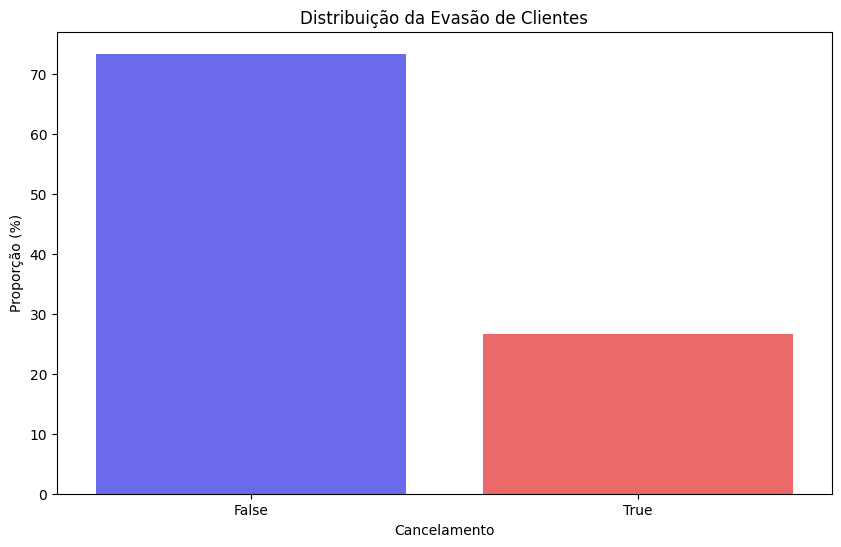


 FREQUENCIA ABSOLUTA:
-----------------------
Cancelamento
False    5163
True     1869
Name: count, dtype: int64
-

 PROPORÇÃO (%):
-----------------
Cancelamento
False    73.421502
True     26.578498
Name: proportion, dtype: float64
-



In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Frequência absoluta e relativa da coluna Cancelamento
frequencia = dados['Cancelamento'].value_counts()
proporcao = dados['Cancelamento'].value_counts(normalize=True) * 100

# Visualizar com gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=proporcao.index, y=proporcao.values, hue=proporcao.index, palette='seismic', legend=False)
plt.ylabel('Proporção (%)')
plt.title('Distribuição da Evasão de Clientes')
plt.show()

# Exibir os resultados
print("\n FREQUENCIA ABSOLUTA:")
print("-" * 23)
print(frequencia)
print("-\n" * 1)
print(" PROPORÇÃO (%):")
print("-" * 17)
print(proporcao)
print("-\n")

### Após rodar seu código, veja:


Equilíbrio ideal: Classes com proporções próximas a 50%/50%, situação ideal para treinamento de modelos.

Desequilíbrio moderado (gerenciável): Proporções em torno de 70%/30% (ex: 70% permaneceram e 30% cancelaram). Nesse cenário, ainda é possível obter bons modelos, especialmente com a aplicação de técnicas de balanceamento.

Desequilíbrio forte: Quando uma classe representa 80% ou mais dos registros (ex: 80% "Não evadiram" e 20% "Evadiram"). Nesse caso, o modelo tende a ignorar a classe minoritária, sendo necessário:

Aplicar técnicas de balanceamento (oversampling com SMOTE, undersampling, entre outras);

Utilizar métricas de avaliação adequadas (como F1-Score, Recall e AUC), evitando reliance apenas na acurácia.

##  <b><font color="blue">Balanceamento de Classes</font></b>

Para aprofundar a análise, foi aplicado técnicas de balanceamento como undersampling , oversampling e SMOTE. Em situações de forte desbalanceamento, ferramentas como o SMOTE podem ser úteis para gerar exemplos sintéticos da classe minoritária.

In [20]:
# Separar features(X) e target(y)
X = dados.drop('Cancelamento', axis=1)
y = dados['Cancelamento']


In [21]:
# Oversampling com RandomOverSampler (Duplica registros da classe minoritária)

from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)

print("DISTRIBUIÇÃO APÓS OVERSAMPLING:")
print("-" * 31)
print(pd.Series(y_res).value_counts())


DISTRIBUIÇÃO APÓS OVERSAMPLING:
-------------------------------
Cancelamento
False    5163
True     5163
Name: count, dtype: int64


In [22]:
# Undersampling com RandomUnderSampler (Remove registros da classe majoritária)
# Gera novas amostras sintéticas da classe minoritária, em vez de apenas copiar.

from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)

print("DISTRIBUIÇÃO APÓS UNDERSAMPLING:")
print("-" * 32)
print(pd.Series(y_res).value_counts())


DISTRIBUIÇÃO APÓS UNDERSAMPLING:
--------------------------------
Cancelamento
False    1869
True     1869
Name: count, dtype: int64


In [23]:
# SMOTE (Synthetic Minority Over-sampling Technique)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("DISTRIBUIÇÃO APÓS SMOTE:")
print("-" * 24)
print(pd.Series(y_res).value_counts())



DISTRIBUIÇÃO APÓS SMOTE:
------------------------
Cancelamento
False    5163
True     5163
Name: count, dtype: int64


###  **Balanceamento de Classes**

Antes de criar os modelos, analisamos a proporção das classes na variável-alvo Cancelamento (0 = cliente permaneceu, 1 = cliente evadiu). Identificamos um desequilíbrio entre as classes, o que poderia prejudicar a detecção de clientes com maior chance de evasão.

Para resolver isso, testamos três técnicas de balanceamento:

RandomOverSampler: duplica exemplos da classe minoritária.

RandomUnderSampler: remove exemplos da classe majoritária.

SMOTE: cria exemplos sintéticos da classe minoritária.

Optamos pelo SMOTE, pois ele gera dados novos sem repetir informações, reduzindo o risco de overfitting.

Com os dados balanceados, treinamos e avaliamos os modelos usando métricas como precisão, recall, f1-score e matriz de confusão. Os resultados serão apresentados a seguir.



##   <b><font color="blue">Normalização ou Padronização (se necessário)</font></b>

Avaliamos a necessidade de normalizar ou padronizar os dados conforme o modelo a ser aplicado:

Modelos baseados em distância (KNN, SVM, Regressão Logística, Redes Neurais) → exigem esse pré-processamento.

Modelos baseados em árvore (Decision Tree, Random Forest, XGBoost) → não são sensíveis à escala dos dados.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar X e y
X = dados.drop(columns=['Cancelamento'])
y = dados['Cancelamento']

# Dividir treino e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Identificar colunas numéricas para padronizar
colunas_numericas = ['Meses_de_Contrato', 'Valor_Mensal']

# Criar cópias para não modificar original
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Aplicar StandardScaler só nas colunas numéricas
scaler = StandardScaler()
X_train_scaled[colunas_numericas] = scaler.fit_transform(X_train[colunas_numericas])
X_test_scaled[colunas_numericas] = scaler.transform(X_test[colunas_numericas])

# Agora se pode usar X_train_scaled e X_test_scaled para treinar modelos sensíveis à escala.


###  **Normalização / Padronização dos Dados**

No pré-processamento, aplicamos a padronização dos atributos numéricos com o StandardScaler, que transforma os dados para média zero e desvio padrão um.

Esse passo é essencial para modelos sensíveis à escala, como:

KNN, SVM, Regressão Logística e Redes Neurais

A padronização foi feita após o balanceamento e a divisão entre treino e teste, evitando vazamento de dados e garantindo uma avaliação justa dos modelos.


 <b><font color="blue" size="4">CORRELAÇÃO E SELEÇÃO DE VARIÁVEIS</font></b>



## <b><font color="blue">Análise de Correlação</font></b>

A matriz de correlação é útil para identificar relações entre variáveis numéricas. Observe especialmente quais variáveis apresentam maior correlação com a evasão.

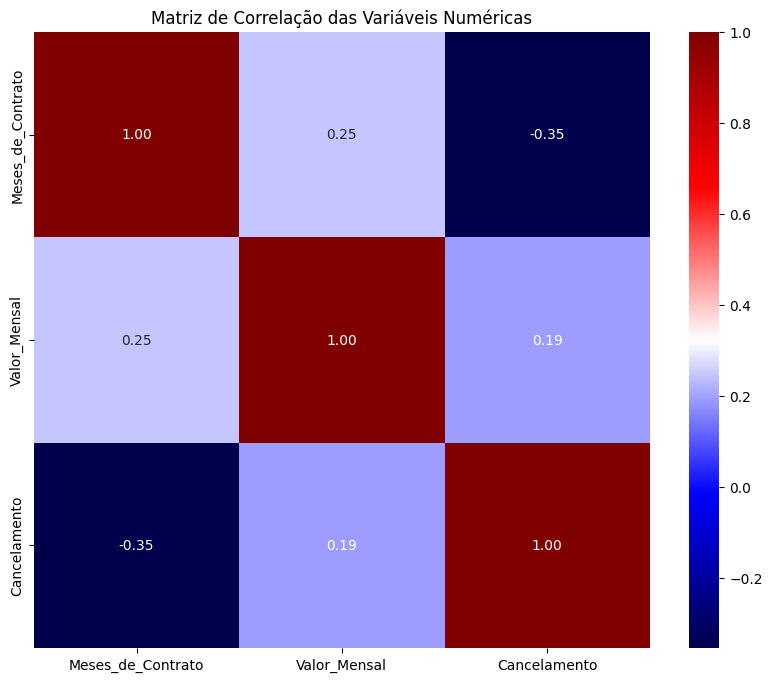

In [25]:
# Identificar as colunas numéricas automaticamente
colunas_numericas = dados.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Para garantir que a coluna alvo 'Cancelamento' esteja incluída
if 'Cancelamento' not in colunas_numericas:
    colunas_numericas.append('Cancelamento')

# Criar um DataFrame apenas com as colunas numéricas
dados_numericos = dados[colunas_numericas]


# Calcular matriz de correlação
corr = dados_numericos.corr()

# Visualizar matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='seismic', fmt=".2f", square=True)
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()


# Analisar correlação com evasão ---
corr_com_alvo = corr['Cancelamento'].drop('Cancelamento').sort_values(ascending=False)


###  **Análise de Correlação**

Utilizamos a matriz de correlação para identificar relações entre as variáveis numéricas e a variável-alvo Cancelamento. As únicas variáveis numéricas contínuas são Meses_de_Contrato e Valor_Mensal (as demais são binárias).

Os resultados obtidos foram:

Correlação entre Meses_de_Contrato e Valor_Mensal: 0,25 (fraca)

Correlação entre Meses_de_Contrato e Cancelamento: 0,35 (fraca)

Correlação entre Valor_Mensal e Cancelamento: 0,19 (fraca)


**Conclusão:** Não há relação linear forte entre tempo de contrato, valor mensal e cancelamento.

##  <b><font color="seismic">Análise Direcionadas</font></b>

Nesta etapa, analisamos como duas variáveis principais — **Meses de Contrato** e **Valor Mensal** — se comportam em relação ao **Cancelamento (Evasão)** dos clientes.

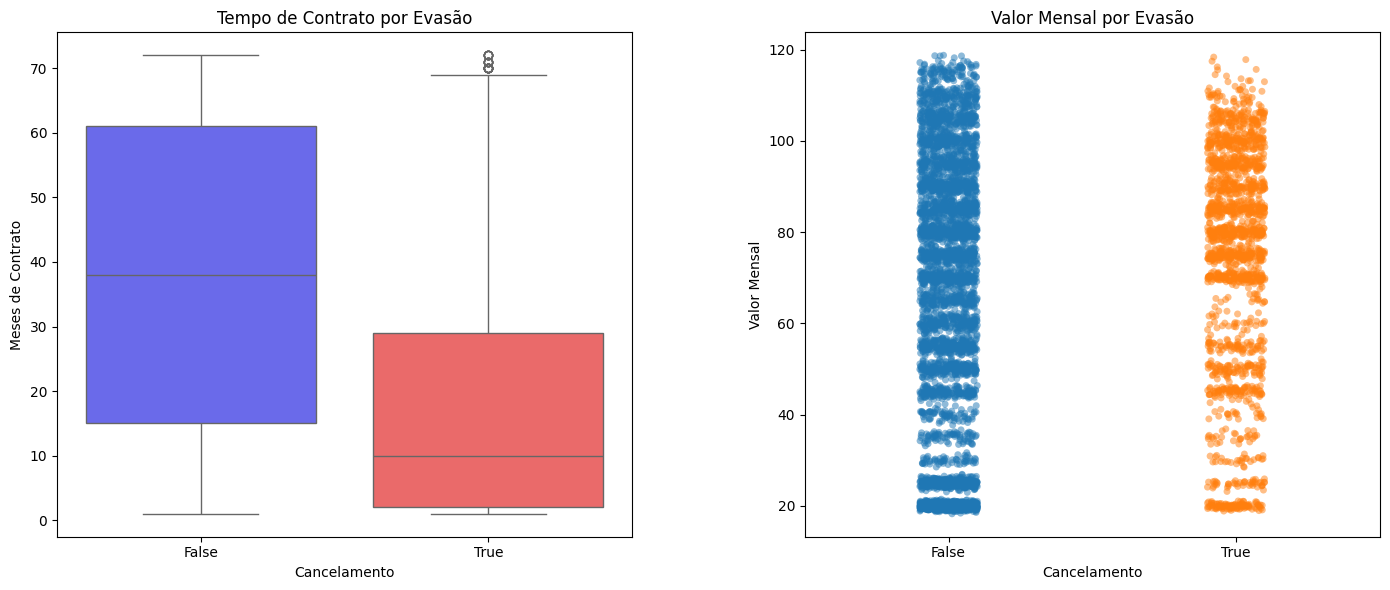

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 linha, 2 colunas

# Boxplot com hue e legend=False para evitar warning
sns.boxplot(ax=axes[0], x='Cancelamento', y='Meses_de_Contrato', hue='Cancelamento', palette='seismic', data=dados, legend=False)
axes[0].set_title('Tempo de Contrato por Evasão',fontsize=12)
axes[0].set_ylabel('Meses de Contrato')

sns.stripplot(ax=axes[1], x='Cancelamento', y='Valor_Mensal', hue='Cancelamento',jitter=True, alpha=0.5, data=dados, legend=False)
axes[1].set_title('Valor Mensal por Evasão', fontsize=12)
axes[1].set_ylabel('Valor Mensal')

plt.tight_layout()

# Aumenta o espaço horizontal entre os gráficos
plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()



###  **Análise Direcionada**


---

####  **Gráfico 1**: *Boxplot - Tempo de Contrato por Evasão*


O gráfico compara a distribuição dos meses de contrato entre clientes que permaneceram (0) e evadiram (1).

Interpretação:
Clientes que cancelaram tendem a ter menos tempo de contrato. Isso sugere que a evasão é mais comum nos primeiros meses.


---

####  **Gráfico 2**: *Stripplot - Valor Mensal por Evasão*

O gráfico mostra o valor mensal pago por cada cliente, separado entre os que permaneceram e os que evadiram.

Interpretação:
Há uma concentração maior de valores mensais altos entre os clientes que cancelaram. Isso indica que valores mais elevados podem estar associados à evasão.



** Interpretação:**

Apesar de haver sobreposição, é possível notar uma **concentração maior de valores mensais mais altos entre os clientes que evadiram (1)**, sugerindo que **valores mais elevados podem estar relacionados à evasão**.

---

Esses dois gráficos ajudam a entender melhor **quais fatores estão associados à decisão dos clientes em cancelar os serviços.**


# <b><font color="blue" size="4">MODELAGEM PREDITIVA</font></b>

In [6]:
import pandas as pd
import gdown
import warnings

# --- Carregamento de Dados e Pré-processamento Inicial (proveniente de células anteriores) ---
# ID do arquivo no Google Drive
file_id = '1Dul9YDaHCzXo8jFJKceEhzarRkjwLYnK'
url = f'https://drive.google.com/uc?id={file_id}'

# Baixar o arquivo
gdown.download(url, 'dados_tratados.csv', quiet=True)

# Ler os dados
dados = pd.read_csv('dados_tratados.csv')

# Remover colunas irrelevantes e registros 'Não informado' (proveniente de VHNXATcs2His)
dados = dados.drop(['ID_Cliente', 'tempo_estimado_meses', 'Conta_Diarias', 'Valor_Total'], axis=1)
dados = dados[dados['Cancelamento'] != 'Não informado']

# Mapear valores para binário (proveniente de y8VQrd4H2tBd)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)
    dados = dados.replace({'Yes': 1, 'No': 0})
    dados = dados.replace({'Female': 1, 'Male': 0})
    dados = dados.replace({'True': 1, 'False': 0})

# Converter colunas binárias para booleano (proveniente de pJPQpS_jPV3O)
binarias = [col for col in dados.columns if set(dados[col].dropna().unique()).issubset({0, 1})]
dados[binarias] = dados[binarias].astype(bool)

# One-hot encoding para colunas categóricas multiclasse (proveniente de EgLXe9xFaAvM)
dados = pd.get_dummies(dados, drop_first=True)

# Remover colunas com alta correlação (proveniente de KEggGRXodMXY)
dados = dados.drop([ 'Multiplas_Linhas_No phone service',
    'Backup_Online_No internet service',
    'Protecao_Dispositivo_No internet service',
    'Suporte_Tecnico_No internet service',
    'Streaming_TV_No internet service',
    'Streaming_Filmes_No internet service'], axis=1, errors='ignore')

# --- Conteúdo original de 0b7f44c0 ---
# Separar features(X) e target(y)
X = dados.drop(['Cancelamento'], axis=1)
y = dados['Cancelamento']

## <b><font color="blue">Separação de Dados</font></b>

Uma divisão comum é 70% para treino e 30% para teste, podendo ser também 80/20, a depender do tamanho da base de dados.

In [9]:
from sklearn.model_selection import train_test_split

# Dividir treino e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

## <b><font color="seismic">Criação de Modelos</font></b>

foram criados 4 modelos diferentes para prever a evasão de clientes:

 - *Regressão Logística* e *KNN* que exige normalização.

 - *Árvore de Decisão* e *Random Forest* que não exige normalização.


In [10]:
# MODELO 1: Regressão Logística (com normalização)

# Importações necessárias
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# MODELO 1: Regressão Logística (com normalização)

# Normalização apenas para o Modelo 1
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

# Treinar modelo com dados normalizados
modelo_logistico = LogisticRegression()
modelo_logistico.fit(X_train_norm, y_train)

# Previsões
y_pred_log = modelo_logistico.predict(X_test_norm)

# Avaliação
print("🔍 REGRESSÃO LOGÍSTICA")
print("-" * 30)
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_log))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_log))


🔍 REGRESSÃO LOGÍSTICA
------------------------------
Matriz de Confusão:
[[930 103]
 [179 195]]

Relatório de Classificação:
              precision    recall  f1-score   support

       False       0.84      0.90      0.87      1033
        True       0.65      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



In [11]:
# MODELO 2: Random Forest

from sklearn.ensemble import RandomForestClassifier

# Treinar modelo com dados originais
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

# Previsões
y_pred_rf = modelo_rf.predict(X_test)

# Avaliação
print("🌳 RANDOM FOREST")
print("-" * 17)
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

🌳 RANDOM FOREST
-----------------
[[936  97]
 [199 175]]
              precision    recall  f1-score   support

       False       0.82      0.91      0.86      1033
        True       0.64      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



In [12]:
# MODELO 3: KNN - K Vizinhos Mais Próximos (com normalização)
from sklearn.neighbors import KNeighborsClassifier

modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train_norm, y_train)
y_pred_knn = modelo_knn.predict(X_test_norm)

# Avaliação
print("🔍 KNN")
print("-" * 10)
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

🔍 KNN
----------
[[880 153]
 [189 185]]
              precision    recall  f1-score   support

       False       0.82      0.85      0.84      1033
        True       0.55      0.49      0.52       374

    accuracy                           0.76      1407
   macro avg       0.69      0.67      0.68      1407
weighted avg       0.75      0.76      0.75      1407



In [13]:
# MODELO 4: Árvore de Decisão (sem normalização)
from sklearn.tree import DecisionTreeClassifier

modelo_dt = DecisionTreeClassifier(random_state=42)
modelo_dt.fit(X_train, y_train)
y_pred_dt = modelo_dt.predict(X_test)

# Avaliação
print("🌳 ÁRVORE DE DECISÃO")
print("-" * 21)
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


🌳 ÁRVORE DE DECISÃO
---------------------
[[833 200]
 [185 189]]
              precision    recall  f1-score   support

       False       0.82      0.81      0.81      1033
        True       0.49      0.51      0.50       374

    accuracy                           0.73      1407
   macro avg       0.65      0.66      0.65      1407
weighted avg       0.73      0.73      0.73      1407



In [15]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Função para gerar métricas + matriz de confusão como string
def gerar_metricas(nome, modelo, X_test, y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    cm_str = f"[[{cm[0][0]}, {cm[0][1]}], [{cm[1][0]}, {cm[1][1]}]]"

    return {
        'Modelo': nome,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'Matriz de Confusão': cm_str
    }

# Coletar métricas de todos os modelos
resultados = [
    gerar_metricas("Regressão Logística", modelo_logistico, X_test_norm, y_test, y_pred_log),
    gerar_metricas("Random Forest", modelo_rf, X_test, y_test, y_pred_rf),
    gerar_metricas("KNN", modelo_knn, X_test_norm, y_test, y_pred_knn),
    gerar_metricas("Árvore de Decisão", modelo_dt, X_test, y_test, y_pred_dt)
]

# Criar DataFrame
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by='F1-Score', ascending=False)

# Exibir a tabela
print("📊 COMPARATIVO DE MODELOS")
print("-" * 26)
display(df_resultados.round(4))

📊 COMPARATIVO DE MODELOS
--------------------------


,Modelo,Acurácia,Precisão,Recall,F1-Score,Matriz de Confusão
0,Regressão Logística,0.7996,0.6544,0.5214,0.5804,"[[930, 103], [179, 195]]"
1,Random Forest,0.7896,0.6434,0.4679,0.5418,"[[936, 97], [199, 175]]"
2,KNN,0.7569,0.5473,0.4947,0.5197,"[[880, 153], [189, 185]]"
3,Árvore de Decisão,0.7264,0.4859,0.5053,0.4954,"[[833, 200], [185, 189]]"


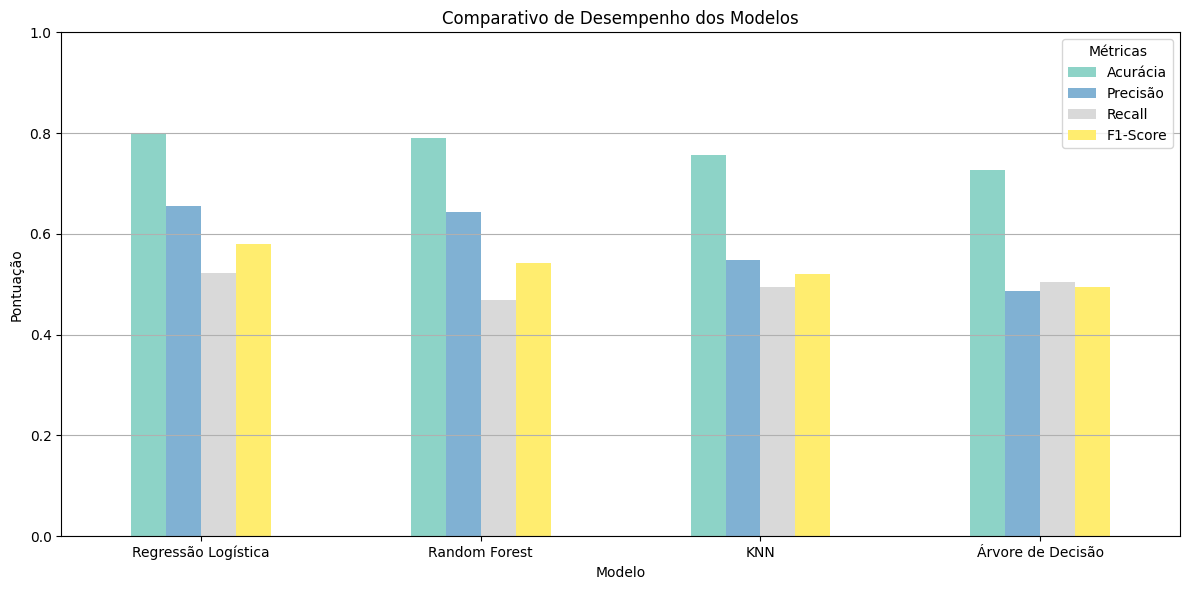

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# Criar DataFrame com os dados fornecidos
dados_modelos = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Random Forest', 'KNN', 'Árvore de Decisão'],
    'Acurácia': [0.7996, 0.7896, 0.7569, 0.7264],
    'Precisão': [0.6544, 0.6434, 0.5473, 0.4859],
    'Recall': [0.5214, 0.4679, 0.4947, 0.5053],
    'F1-Score': [0.5804, 0.5418, 0.5197, 0.4954]
})

# Plotar gráfico de barras para cada métrica
dados_modelos.set_index('Modelo').plot(kind='bar', figsize=(12, 6), colormap='Set3')
plt.title('Comparativo de Desempenho dos Modelos')
plt.ylabel('Pontuação')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.legend(title='Métricas')
plt.tight_layout()
plt.show()

##   <b><font color="seismic">Avaliação dos Modelos </font></b>

Para prever a evasão de clientes, foram utilizados **quatro modelos diferentes**, com e sem normalização. Cada modelo foi avaliado utilizando as seguintes métricas:

- **Acurácia**  
- **Precisão**  
- **Recall**  
- **F1-score**  
- **Matriz de confusão**

<br/>

###  **MODELO 1**: *Regressão Logística* (com normalização)

- Modelo linear, indicado para **classificação binária**.  
- Requer **normalização dos dados**, pois é sensível à escala das variáveis.  
- Fácil de interpretar e útil para identificar variáveis relevantes.  
- Serviu como **modelo base** e apresentou **o melhor desempenho geral** nas métricas.

---

###  **MODELO 2**: *Random Forest* (sem normalização)

- Modelo não linear baseado em múltiplas árvores de decisão.  
- **Não precisa de normalização**, pois suas decisões são baseadas em cortes.  
- Robusto contra overfitting e apto a capturar relações complexas entre variáveis.  
- Teve desempenho sólido, porém com menor recall em comparação à regressão logística.

---

###  **MODELO 3**: *KNN* – K Vizinhos Mais Próximos (com normalização)

- Classifica os clientes com base na **distância dos vizinhos mais próximos**.  
- Requer **normalização**, pois é altamente sensível à escala das variáveis.  
- Simples e intuitivo, mas pode ter **performance inferior com dados desbalanceados**.  
- Apresentou **métricas medianas** e sinal de **underfitting**.

---

###  **MODELO 4**: *Árvore de Decisão* (sem normalização)

- Modelo interpretável baseado em regras do tipo "if-else".  
- **Não exige normalização**.  
- Pode se ajustar bem aos dados, mas é suscetível ao **overfitting** se não regulado.  
- Foi o modelo com **menor desempenho geral**, indicando **underfitting**.

<br/>

###  <b><font color="seismic">**CONCLUSÃO** </font></b>: Modeo Escolhido: **Regressão Logística**

Após aplicar e comparar os quatro modelos (Regressão Logística, Random Forest, KNN e Árvore de Decisão), considerando as métricas de desempenho (Acurácia, Precisão, Recall, F1-Score e Matriz de Confusão), conclui-se:

- 🔹 **Regressão Logística** apresentou o melhor desempenho geral:
  - Maior **acurácia (0.7996)** e **F1-Score (0.5804)**.
  - Bom equilíbrio entre **precisão (0.6544)** e **recall (0.5214)**.
  - Modelo simples, interpretável e eficiente, ideal para começar.

- 🔹 **Random Forest** teve desempenho próximo, porém com recall mais baixo, o que pode impactar a detecção de clientes que realmente evadiriam.

- 🔹 KNN e Árvore de Decisão apresentaram desempenho inferior, com menor F1-Score e sinais de **underfitting** (pouca capacidade de generalização).

<br/>

A <b><font color="seismic">**Regressão Logística** </font></b> é o modelo mais indicado neste cenário, combinando boa performance, fácil aplicação e excelente interpretabilidade para ações estratégicas nas empresas.



# <b><font color="seismic" size="4">INTERPRETAÇÃO & CONCLUSÃO</font></b>

## <b><font color="seismic">Análise de Importância das Variáveis </font></b>

O gráfico abaixo apresenta as variáveis mais relevantes identificadas pelo modelo de Regressão Logística, treinado com dados normalizados, para a previsão de evasão de clientes.

As variáveis posicionadas no topo do gráfico exercem maior influência nas decisões do modelo, considerando a magnitude dos coeficientes. Isso indica que pequenas variações nessas variáveis provocam um impacto significativo na probabilidade de um cliente cancelar os serviços.






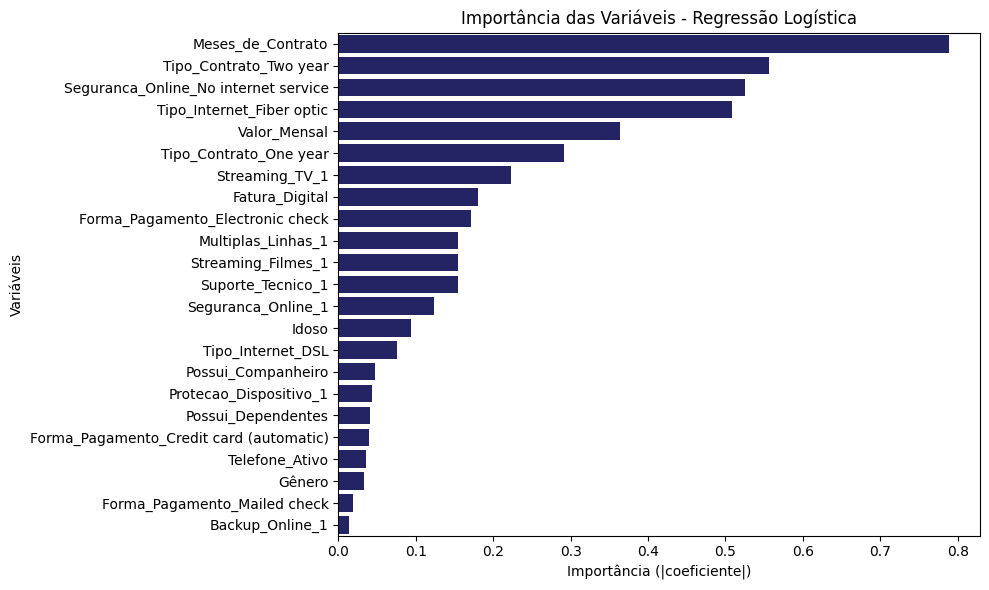

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extrair coeficientes do modelo treinado
coeficientes = modelo_logistico.coef_[0]

# Importância: valor absoluto dos coeficientes
importancias = np.abs(coeficientes)

# Criar DataFrame com variáveis e suas importâncias
df_importancias = pd.DataFrame({
    'Variável': X_train.columns,
    'Importância': importancias
}).sort_values(by='Importância', ascending=False)

# Plotar gráfico com cor única suave, sem legenda e sem warning
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importância',
    y='Variável',
    data=df_importancias,
    color='midnightblue'
)
plt.title('Importância das Variáveis - Regressão Logística')
plt.xlabel('Importância (|coeficiente|)')
plt.ylabel('Variáveis')
plt.tight_layout()
plt.show()

#  <b><font color="seismic">Conclusão Geral da Análise</font></b>

A análise preditiva de evasão de clientes realizada neste projeto possibilitou extrair insights valiosos sobre o comportamento dos usuários e os fatores que mais contribuem para o cancelamento dos serviços.

<br/>

####  <b><font color="seismic">Principais Conclusões:</font></b>

O modelo de Regressão Logística apresentou o melhor desempenho geral entre os algoritmos avaliados, atingindo uma acurácia de aproximadamente 79,96%. Além disso, destacou-se nas métricas mais relevantes para o problema de evasão — Precisão (65,44%) , Recall (52,14%) e F1-Score (58,04%) — que são fundamentais para identificar corretamente os clientes com maior probabilidade de cancelamento.

* Embora o modelo Random Forest também tenha apresentado uma acurácia expressiva (78,96%), seu desempenho foi inferior nas métricas de precisão e recall, tornando-o menos adequado para o objetivo específico de detecção de evasão.

* As variáveis com maior influência nas previsões foram:

* Tempo de Contrato: clientes com contratos mais recentes apresentam maior propensão à evasão.

* Valor Mensal: quanto maior o valor pago, maior a chance de cancelamento.

* Serviços adicionais, como segurança online, backup e suporte técnico, também se mostraram relevantes para explicar o comportamento de evasão.

<br/>

####  <b><font color="seismic">Recomendações Estratégicas:</font></b>

Com base nas análises realizadas, recomenda-se a adoção das seguintes estratégias para mitigação da evasão de clientes:

* Desenvolver ações de retenção específicas para clientes com contratos mais curtos e maior valor mensal, uma vez que esses perfis apresentam risco elevado de cancelamento.

* Oferecer pacotes personalizados ou descontos progressivos como forma de incentivar a fidelização e reduzir a taxa de evasão ao longo do tempo.

* Utilizar o modelo de Regressão Logística para monitoramento contínuo da base de clientes, permitindo a identificação antecipada daqueles com maior probabilidade de cancelamento e viabilizando intervenções proativas.*

<br/>

> * *  Este projeto mostra como o uso de Machine Learning ajuda a empresa a antecipar cancelamentos e direcionar ações estratégicas de retenção, como ofertas personalizadas, melhoria no atendimento ou ajustes nos pacotes de serviços.
